To evaluate PyChemelt's performance on an experimental dataset the DNAJB6b dataset from *Fricke et al.*<sup>1</sup> was processed and used. This datasets provides 17 thermal denaturation curves with differing concentrations of GuHCL. This dataset was thus used to fit the parameters in a 2 dimensional fashion to the curves regarding temperature and chemical denaturation. <br>


<sup>1</sup> Fricke, Celia, et al. "On the thermal and chemical stability of DNAJB6b and its globular domains." Biophysical Chemistry 320 (2025): 107401.*

This notebook is only possible thanks to the publication of the data and associated code.
See https://data.dtu.dk/articles/code/Fitting_of_thermal_and_chemical_denaturation/27679716

In [1]:
from dataclasses import dataclass
from pychemelt import Monomer

import numpy as np
import pandas as pd

from plotly.subplots import make_subplots
from pychemelt.utils.processing import (
    get_colors_from_numeric_values,
    combine_sequences
)

from pychemelt.utils.plotting import *
import plotly.graph_objs as go

from scripts import display_figure_static

In [2]:
@dataclass
class pantasample:
    T: np.ndarray
    f330: np.ndarray
    f350: np.ndarray
    denaturant: float

df=pd.read_csv('../data/nanoDSF_B6.csv', sep = '\t')

# Denaturant concentrations in M
denaturants = [0, 0.08, 0.4, 0.8, 1.2, 1.6, 2, 2.4, 2.8, 3.2, 3.6, 4, 4.4, 4.8, 5.2, 5.6, 6, 6.4]

B6 = [] # List for storing unfolding measurements
for i in range(18):

    temperature = df[df.columns[i*12]].values + 273.15  # Convert to Kelvin

    B6.append(pantasample(df[df.columns[i*12]].values, df[df.columns[i*12+9]].values, df[df.columns[i*12+5]].values, denaturants[i])) 

In [3]:
sample = Monomer()

signal_dic = {}
temp_dic = {}

# Create a signal matrix from each B6 f350 array
signal_matrix = np.array([b6.f350 for b6 in B6])  
temp_matrix = np.array([b6.T for b6 in B6]) 

assert (temp_matrix.shape == signal_matrix.shape)  # Should be True

sample.signal_dic['350nm'] = signal_matrix
sample.temp_dic['350nm'] = temp_matrix

# Create a signal matrix from each B6 f330 array
signal_matrix = np.array([b6.f330 for b6 in B6])  
temp_matrix = np.array([b6.T for b6 in B6]) 

assert (temp_matrix.shape == signal_matrix.shape)  # Should be True

sample.signal_dic['330nm'] = signal_matrix
sample.temp_dic['330nm'] = temp_matrix

conditions = [b6.denaturant for b6 in B6]
sample.conditions = conditions

sample.set_signal(['350nm','330nm'])

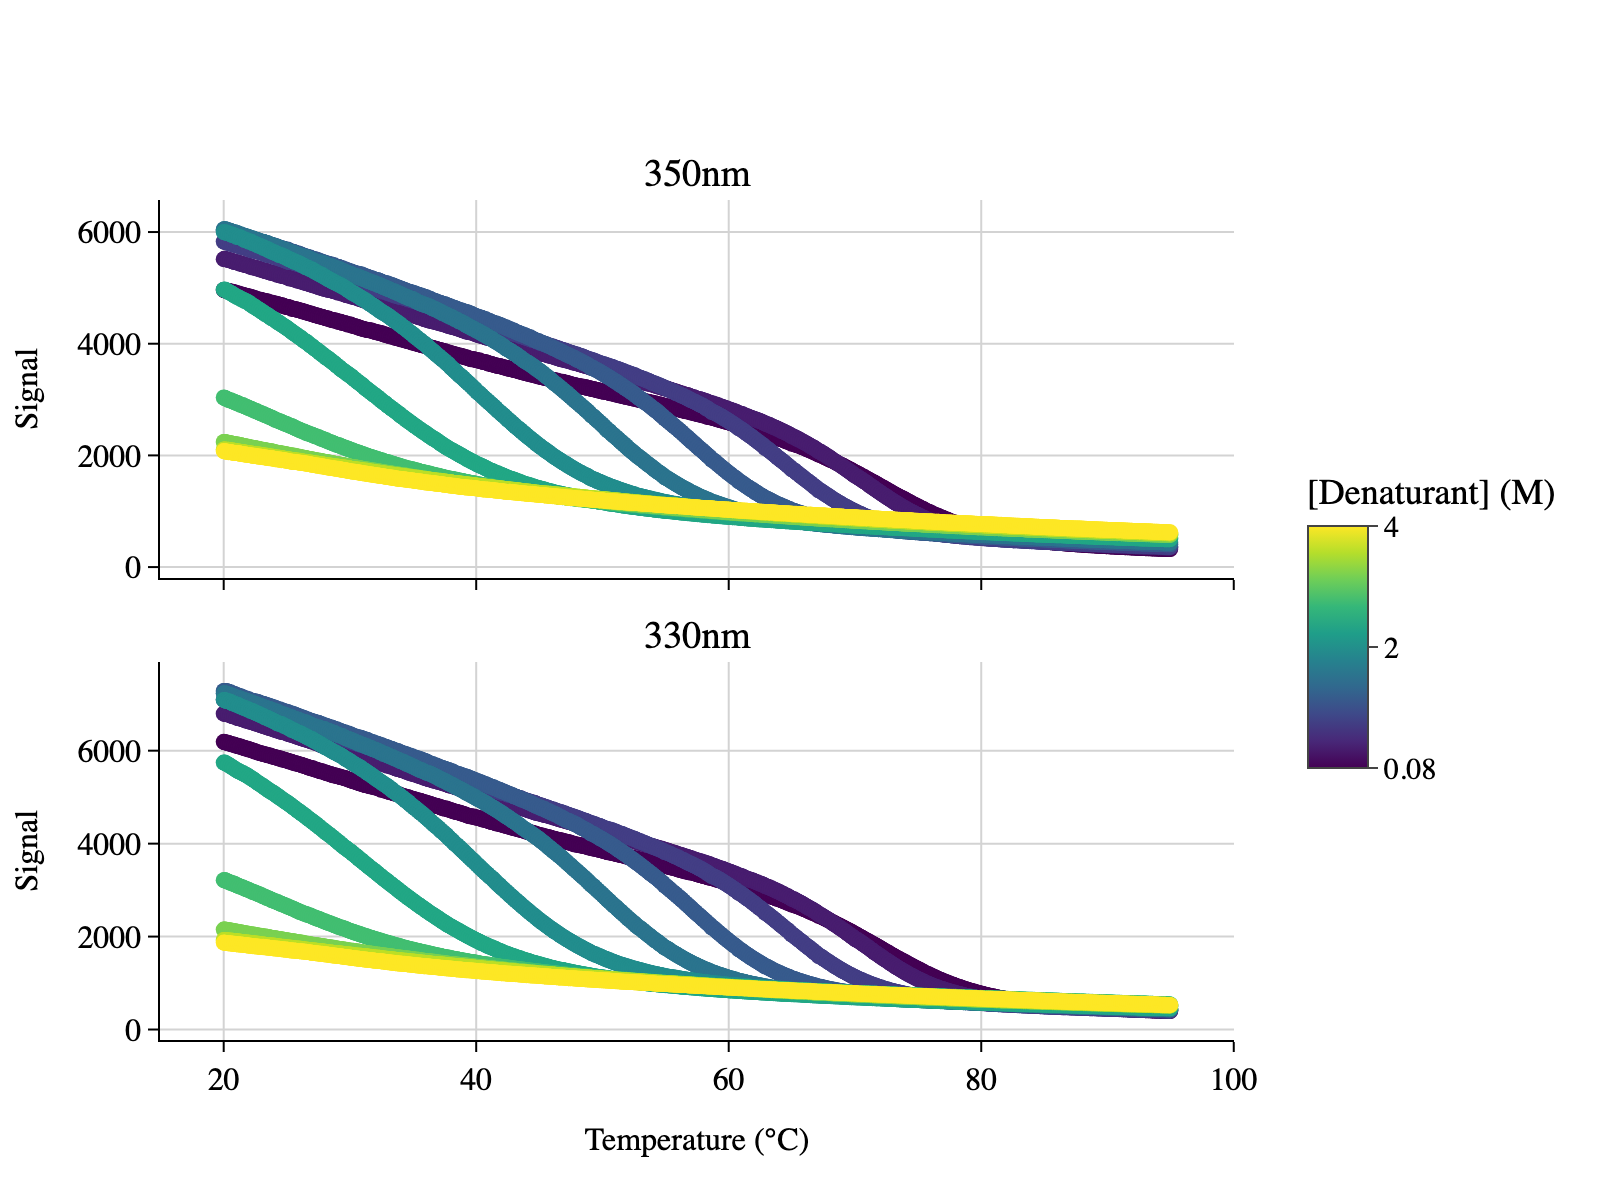

In [4]:

sample.set_denaturant_concentrations()
selected = [False] + [True] * 11 + [False] * 6
sample.select_conditions(selected,normalise_to_global_max=False)
sample.estimate_derivative()
sample.expand_multiple_signal()

fig = plot_unfolding(sample)
display_figure_static(fig,height=600)

In [5]:
sample.global_min_temp = 20
sample.global_max_temp = 95
sample.expand_multiple_signal()

sample.estimate_baseline_parameters(
        native_baseline_type='linear',
        unfolded_baseline_type='exponential'
    )

sample.fit_thermal_unfolding_local()
sample.n_residues = 150 # For an initial guess of Cp, we need to set the number of residues in the sample
sample.guess_Cp()

In [6]:
# Do a fitting with global thermodynamic parameters, but local intercept terms and local slope terms
sample.fit_thermal_unfolding_global()

In [7]:
# Do a fitting with global thermodynamic parameters, local intercept terms and global slope terms
sample.fit_thermal_unfolding_global_global()

In [8]:
# Do a fitting with global thermodynamic parameters, global intercept terms and global slope terms
sample.fit_thermal_unfolding_global_global_global()

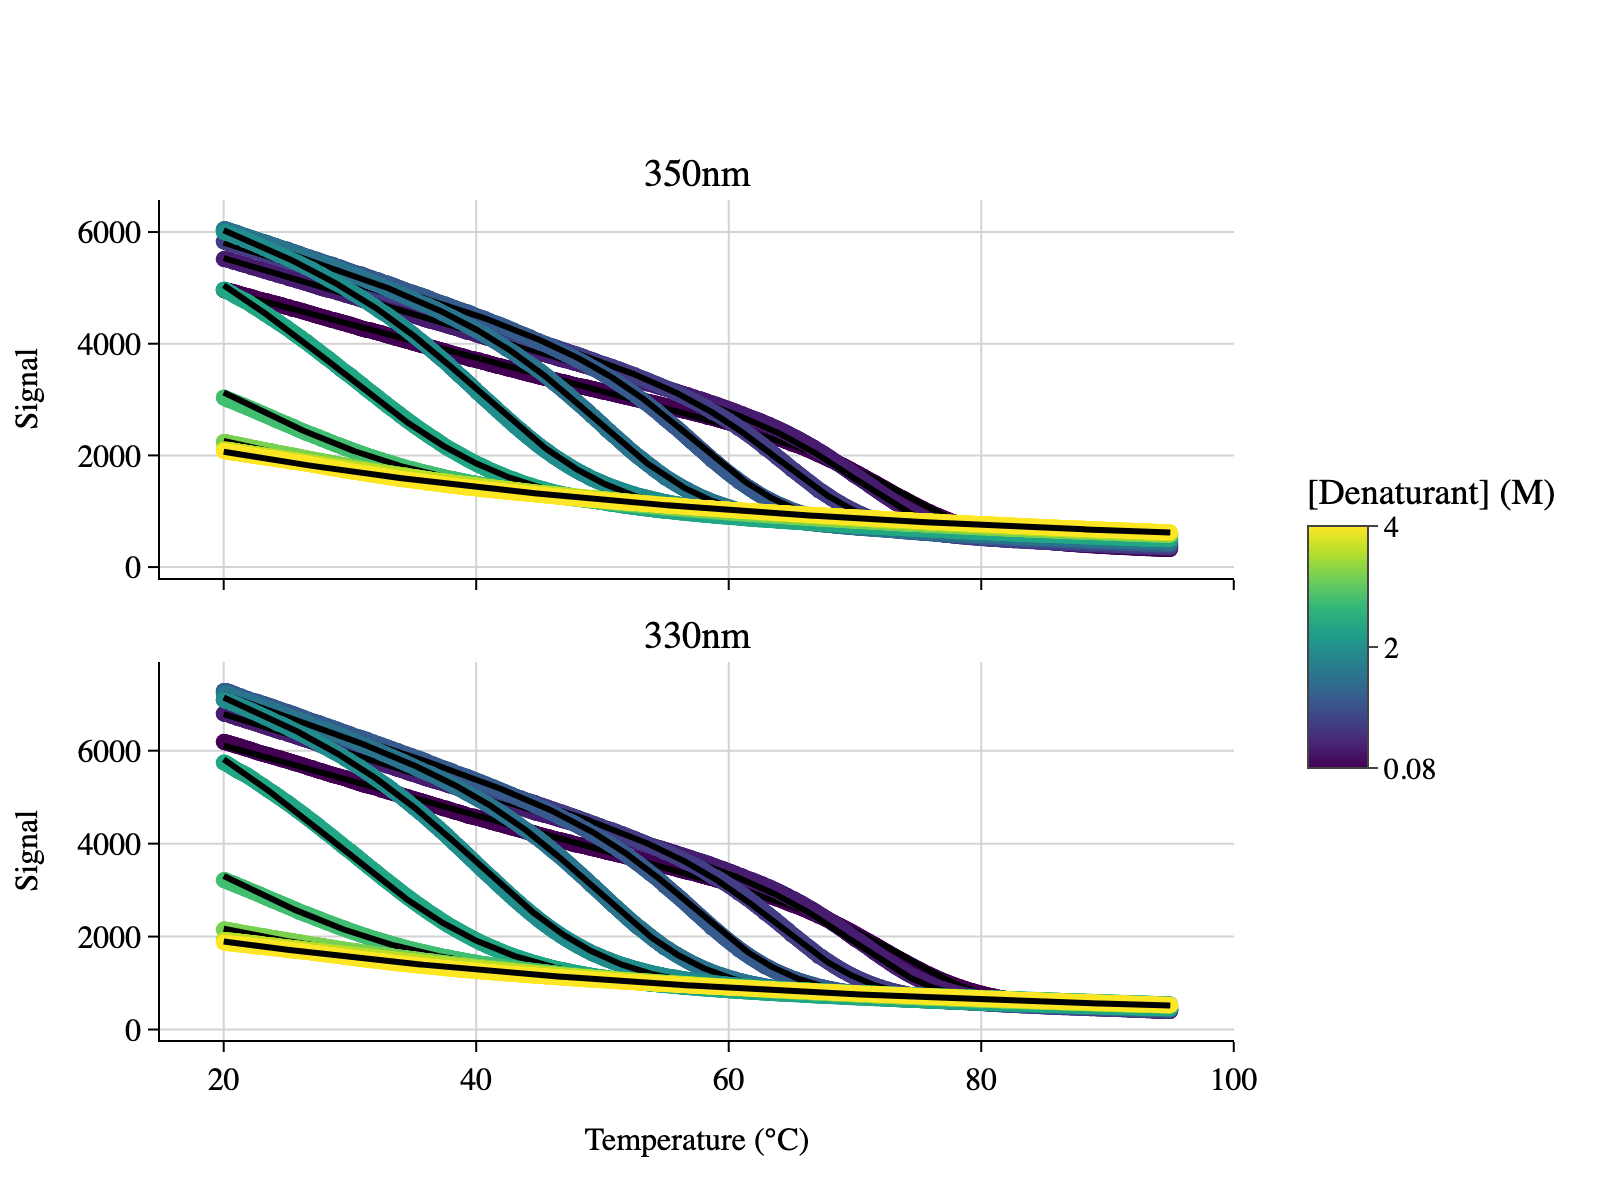

In [9]:
fig = plot_unfolding(sample)
display_figure_static(fig,height=600)

In [10]:
sample.create_fit_report()
print(sample.fit_report)

[[Fit Statistics]]
    # fitting method   = least_squares
    # function evals   = 84
    # data points      = 20328
    # variables        = 27
    chi-square         = 18103601.6
    reduced chi-square = 891.759106
    Akaike info crit   = 138119.071
    Bayesian info crit = 138332.904
[[Variables]]
    Tm:     350.644837 +/- 0.01540391 (0.00%) (init = 350.6448)
    DHm:    73.9181214 +/- 0.11099130 (0.15%) (init = 73.91623)
    Cp0:    0.90210733 +/- 0.00225125 (0.25%) (init = 0.9022009)
    m0:     2.96672413 +/- 0.00363985 (0.12%) (init = 2.966911)
    p2N_0:  5661.25836 +/- 12.2138335 (0.22%) (init = 5661.257)
    p2N_1:  6991.96579 +/- 14.9785876 (0.21%) (init = 6991.964)
    p2U_0: -0.06973996 +/- 4.27560625 (6130.78%) (init = -0.06973996)
    p2U_1:  123.489532 +/- 4.28932401 (3.47%) (init = 123.4895)
    p3N_0: -73.1724480 +/- 0.14612549 (0.20%) (init = -73.17244)
    p3N_1: -91.2622189 +/- 0.17908762 (0.20%) (init = -91.26221)
    p3U_0:  1626.41072 +/- 4.03859312 (0.25%) (i

In [11]:
# Estimate the asymmetric confidence intervals for the fitted parameters using the profile likelihood method
sample.calculate_confidence_intervals(percentage=0.95)
print(sample.ci_df)

  Parameter  Lower_CI_95.0%  Value  Upper_CI_95.0%
0   Tm (°C)           77.49  77.49           77.51
1        ΔH           73.91  73.92           73.95
2       ΔCp            0.90   0.90            0.90
3   m-value            2.97   2.97            2.97


In [17]:
# Print it in joules per mole
report_joules = sample.ci_df.copy()
# Add 273.15 to the first row, after the first column, which is the parameter name
report_joules.iloc[0,1:] = report_joules.iloc[0,1:] + 273.15
# Multiply the second, third and fourth rows by 4.184 * 1000
report_joules.iloc[1,1:] = report_joules.iloc[1,1:] * 4.184 * 1000
report_joules.iloc[2,1:] = report_joules.iloc[2,1:] * 4.184 * 1000
report_joules.iloc[3,1:] = report_joules.iloc[3,1:] * 4.184 * 1000
report_joules['Parameter'] = ['Tm (K)', 'Delta H (J/mol)', 'Delta Cp (J/mol/K)', 'm-value (J/mol/M)']
print(report_joules)

            Parameter  Lower_CI_95.0%      Value  Upper_CI_95.0%
0              Tm (K)          350.64     350.64          350.66
1     Delta H (J/mol)       309239.44  309281.28       309406.80
2  Delta Cp (J/mol/K)         3765.60    3765.60         3765.60
3   m-value (J/mol/M)        12426.48   12426.48        12426.48
